# T3.2 Analizar e visualizar estatísticas de datos baixados de MongoDB
## Conexión a MongoDB dende Python e análise de datos

En Atlas mete o dataset de exemplo na túa base de datos.

Engade o enderezo IP autorizado a conectar para que poidas conectar á base de datos.

Proba a conectar dende compass coa URL de conexión que che da.

Da BBDD de proba: sample_mfix, na colección movies: https://www.mongodb.com/docs/atlas/sample-data/sample-mflix/

Conecta a Atlas dende Python, carga a colección en Pandas. Averigua o modo máis adecuado.

In [ ]:
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt

# Conexión a MongoDB
HOST = "cluster0.nl8aj.mongodb.net"
USERNAME = "madalinismana365"
PASSWORD = "xxxxxxxxxxxxx"  # Reemplaza con tu contraseña

client = MongoClient(f"mongodb+srv://{USERNAME}:{PASSWORD}@{HOST}/test")
db_mflix = client['sample_mflix']

# Cargar la colección movies en un DataFrame de Pandas
movies = pd.DataFrame(list(db_mflix.movies.find()))

A) Contar o total de películas.


In [5]:
total_movies = len(movies)
print(f"A) Total de películas: {total_movies}")

A) Total de películas: 21349


B) Contar o número de películas de cada xénero.


B) Películas por género:
genres
Drama          12385
Comedy          6532
Romance         3318
Crime           2457
Thriller        2454
Action          2381
Adventure       1900
Documentary     1834
Horror          1470
Biography       1269
Name: count, dtype: int64


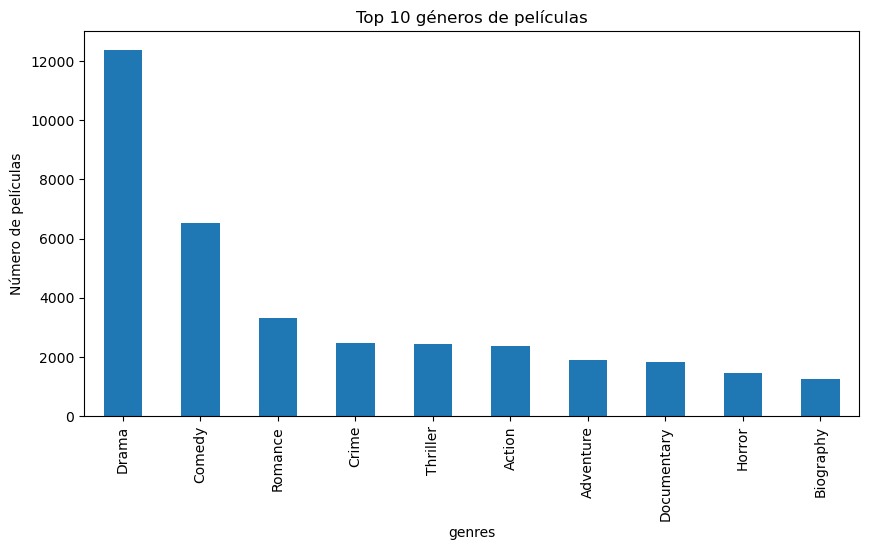

In [6]:
# Desanidar los géneros y contar
genres_counts = movies.explode('genres')['genres'].value_counts().head(10)
print("\nB) Películas por género:")
print(genres_counts)

# Visualización
genres_counts.plot(kind='bar', figsize=(10, 5), title='Top 10 géneros de películas')
plt.ylabel('Número de películas')
plt.show()

C) Contar cantas películas hai por ano.


C) Películas por año (mostrando algunos años):
year
1896      2
1959     71
2009    917
Name: count, dtype: int64


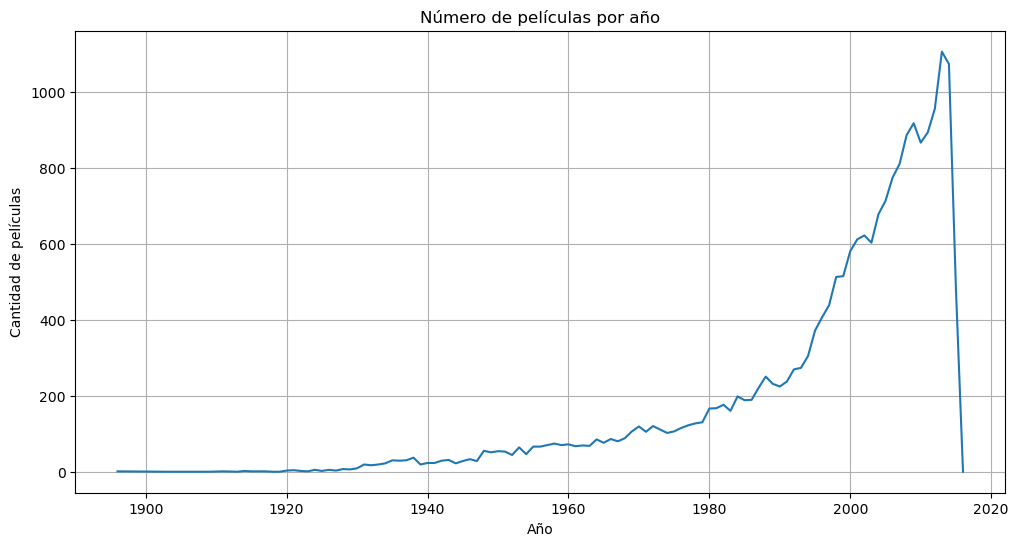

In [8]:
# Filtrar años válidos y contar
movies['year'] = movies['year'].astype(str)  # Convertir a string para filtrar
valid_years = movies[movies['year'].str.isdigit()]  # Filtrar solo valores numéricos
year_counts = valid_years['year'].astype(int).value_counts().sort_index()
print("\nC) Películas por año (mostrando algunos años):")
print(year_counts.iloc[::50])  # Mostrar cada 50 años

# Visualización de la evolución temporal
plt.figure(figsize=(12, 6))
year_counts.plot()
plt.title('Número de películas por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de películas')
plt.grid(True)
plt.show()

D) Mirar se hai correlación entre imdb e rotten tomatoes.


D) Correlación entre IMDB y Rotten Tomatoes: 0.41


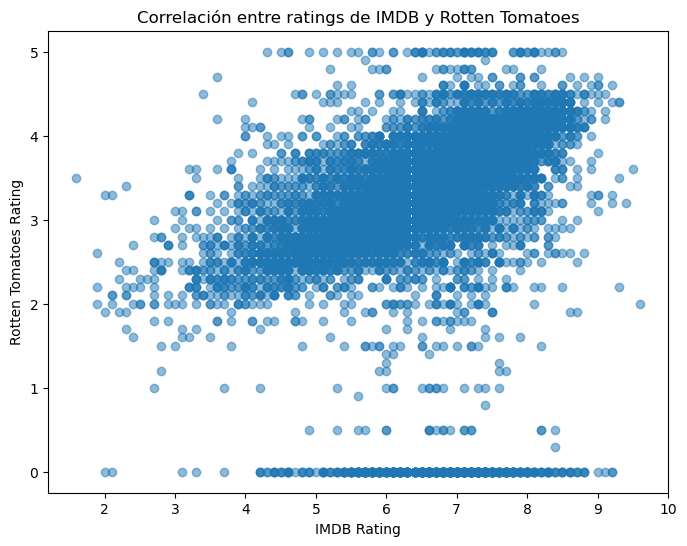


Ejemplos de ratings:
                                               title  imdb_rating  \
0                            The Great Train Robbery          7.4   
1                                  A Corner in Wheat          6.6   
2  Winsor McCay, the Famous Cartoonist of the N.Y...          7.3   
3                                   Traffic in Souls          6.0   
4                                Gertie the Dinosaur          7.3   
5                    In the Land of the Head Hunters          5.8   
6                              The Perils of Pauline          7.6   
7                                        The Italian          6.4   
8                                       Regeneration          6.8   
9                                       Civilization          6.3   

   tomatoes_rating  
0              3.7  
1              3.6  
2              3.4  
3              3.0  
4              3.7  
5              2.7  
6              2.8  
7              4.0  
8              3.4  
9       

In [9]:
# Crear DataFrame con ratings
ratings = movies.copy()
ratings = ratings[ratings['imdb'].notna() & ratings['tomatoes'].notna()]
ratings['imdb_rating'] = ratings['imdb'].apply(lambda x: x.get('rating', None) if isinstance(x, dict) else None)
ratings['tomatoes_rating'] = ratings['tomatoes'].apply(lambda x: x.get('viewer', {}).get('rating', None) if isinstance(x, dict) else None)

# Convertir a numérico y eliminar valores faltantes
ratings['imdb_rating'] = pd.to_numeric(ratings['imdb_rating'], errors='coerce')
ratings['tomatoes_rating'] = pd.to_numeric(ratings['tomatoes_rating'], errors='coerce')
ratings = ratings.dropna(subset=['imdb_rating', 'tomatoes_rating'])

# Calcular correlación
correlation = ratings['imdb_rating'].corr(ratings['tomatoes_rating'])
print(f"\nD) Correlación entre IMDB y Rotten Tomatoes: {correlation:.2f}")

# Visualización
plt.figure(figsize=(8, 6))
plt.scatter(ratings['imdb_rating'], ratings['tomatoes_rating'], alpha=0.5)
plt.title('Correlación entre ratings de IMDB y Rotten Tomatoes')
plt.xlabel('IMDB Rating')
plt.ylabel('Rotten Tomatoes Rating')
plt.show()

# Mostrar algunos ejemplos
print("\nEjemplos de ratings:")
print(ratings[['title', 'imdb_rating', 'tomatoes_rating']].head(10))

E) Contar cantas películas ten cada director


E) Top 10 directores con más películas:
directors
Woody Allen         40
Martin Scorsese     32
Takashi Miike       31
Steven Spielberg    29
Sidney Lumet        29
John Ford           29
Clint Eastwood      27
Spike Lee           27
Michael Apted       27
Robert Altman       27
Name: count, dtype: int64


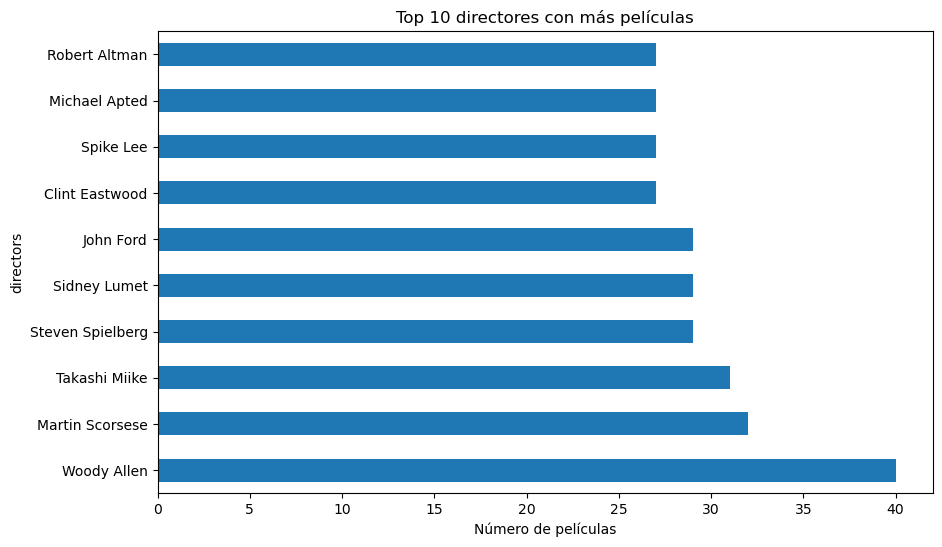

In [10]:
# Desanidar directores y contar
directors_counts = movies.explode('directors')['directors'].value_counts().head(10)
print("\nE) Top 10 directores con más películas:")
print(directors_counts)

# Visualización
directors_counts.plot(kind='barh', figsize=(10, 6), title='Top 10 directores con más películas')
plt.xlabel('Número de películas')
plt.show()

F) Contar en cantas películas ten participado cada actor


F) Top 10 actores con más participaciones:
cast
Gèrard Depardieu       67
Robert De Niro         58
Michael Caine          51
Bruce Willis           49
Samuel L. Jackson      48
Morgan Freeman         48
Christopher Plummer    47
Gene Hackman           46
Max von Sydow          45
Nicolas Cage           45
Name: count, dtype: int64


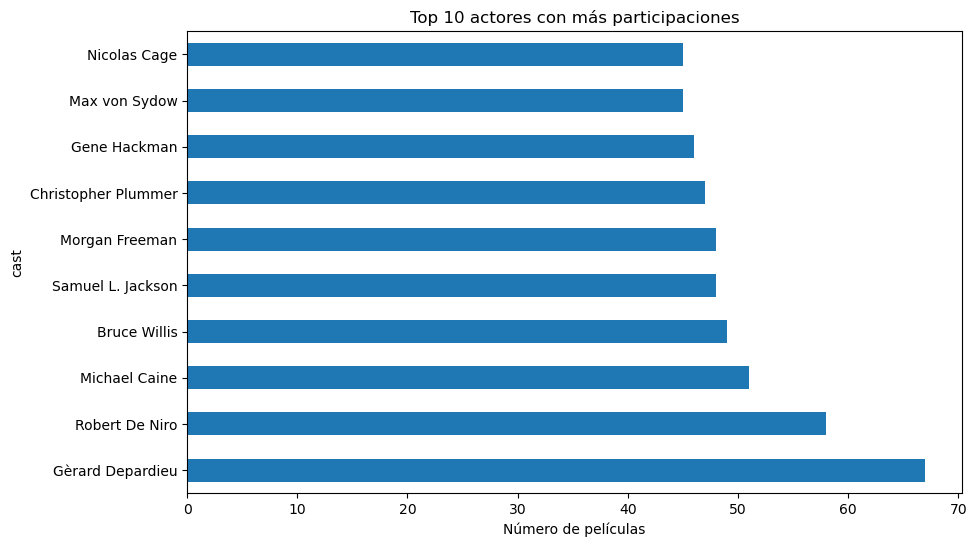

In [11]:
# Desanidar actores y contar
actors_counts = movies.explode('cast')['cast'].value_counts().head(10)
print("\nF) Top 10 actores con más participaciones:")
print(actors_counts)

# Visualización
actors_counts.plot(kind='barh', figsize=(10, 6), title='Top 10 actores con más participaciones')
plt.xlabel('Número de películas')
plt.show()

G) Contar cantas películas hai de cada idioma


G) Top 10 idiomas con más películas:
languages
English       14639
French         2405
Spanish        1600
German         1377
Italian        1228
Japanese        860
Russian         845
Mandarin        478
Hindi           464
Portuguese      346
Name: count, dtype: int64


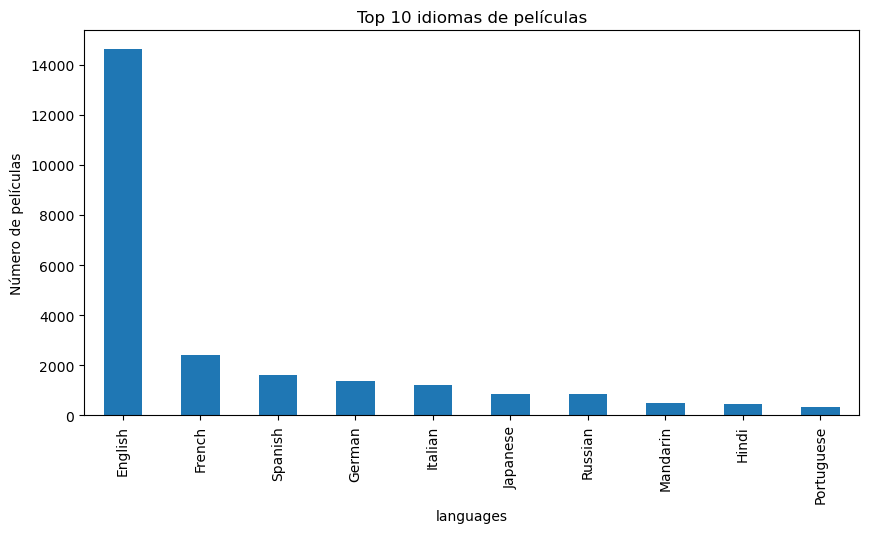

In [12]:
# Desanidar idiomas y contar
languages_counts = movies.explode('languages')['languages'].value_counts().head(10)
print("\nG) Top 10 idiomas con más películas:")
print(languages_counts)

# Visualización
languages_counts.plot(kind='bar', figsize=(10, 5), title='Top 10 idiomas de películas')
plt.ylabel('Número de películas')
plt.show()

H) Cal é a media de premios das películas


H) Media de premios:
Victorias promedio: 4.06
Nominaciones promedio: 4.83


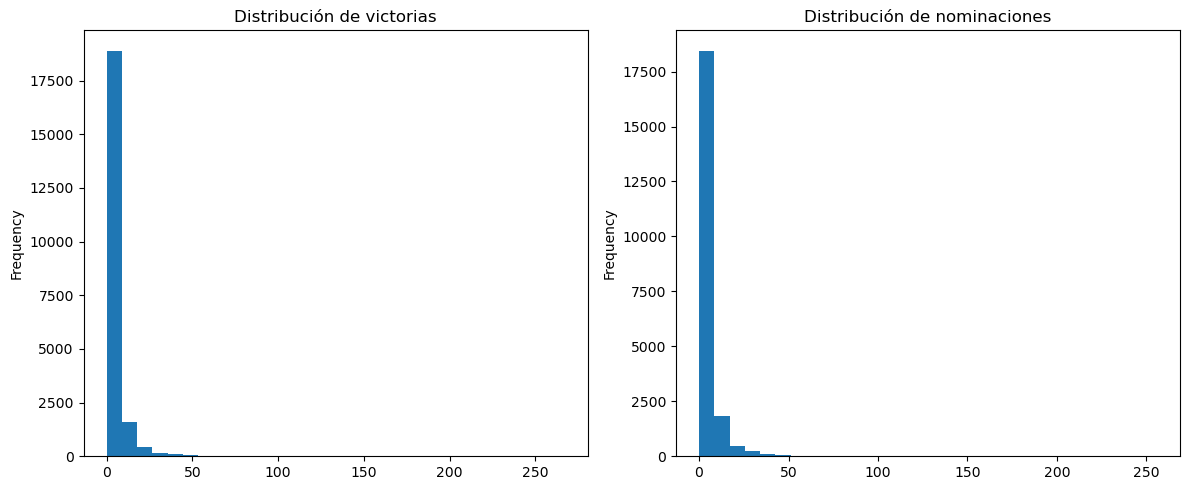

In [13]:
# Extraer información de premios
movies['awards_wins'] = movies['awards'].apply(lambda x: x.get('wins', 0) if isinstance(x, dict) else 0)
movies['awards_nominations'] = movies['awards'].apply(lambda x: x.get('nominations', 0) if isinstance(x, dict) else 0)

# Calcular promedios
avg_wins = movies['awards_wins'].mean()
avg_nominations = movies['awards_nominations'].mean()
print(f"\nH) Media de premios:")
print(f"Victorias promedio: {avg_wins:.2f}")
print(f"Nominaciones promedio: {avg_nominations:.2f}")

# Distribución de premios
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
movies['awards_wins'].plot(kind='hist', bins=30, title='Distribución de victorias')
plt.subplot(1, 2, 2)
movies['awards_nominations'].plot(kind='hist', bins=30, title='Distribución de nominaciones')
plt.tight_layout()
plt.show()

J) Amosar as películas que teñen alomenos 3 premios


J) Películas con al menos 3 premios (top 10):
                                                  title  awards_wins
18550                                  12 Years a Slave          267
17215                                           Gravity          231
16596                                           Gravity          231
19838  Birdman: Or (The Unexpected Virtue of Ignorance)          210
14868                                           Boyhood          185
8213      The Lord of the Rings: The Return of the King          175
13169                            No Country for Old Men          172
15908                                The Social Network          171
16293                                         Inception          162
17414                                        The Artist          161


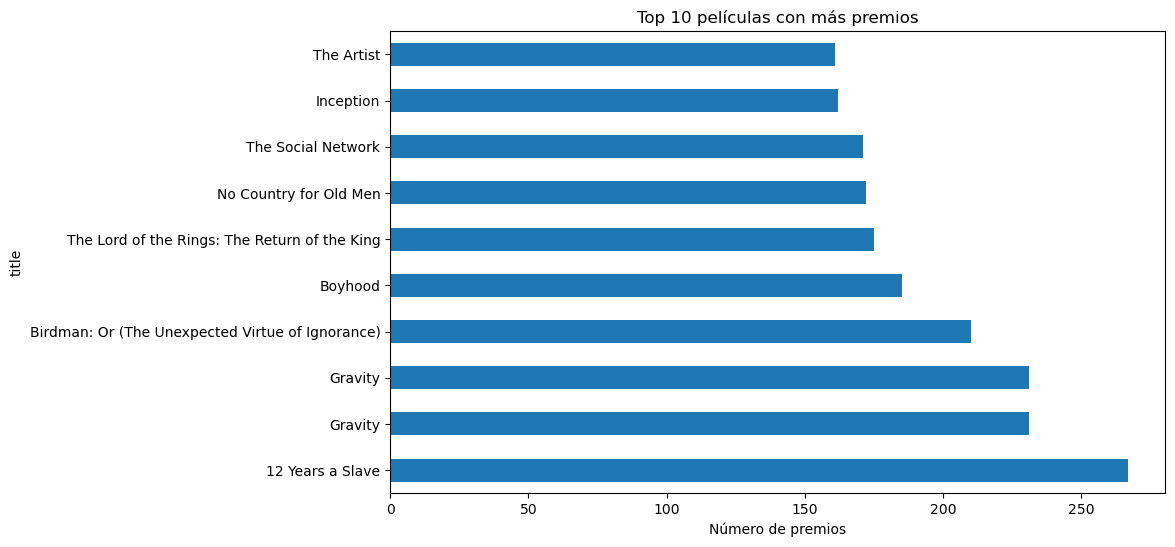

In [14]:
# Filtrar películas con al menos 3 premios
top_awarded = movies[movies['awards_wins'] >= 3][['title', 'awards_wins']].sort_values('awards_wins', ascending=False).head(10)
print("\nJ) Películas con al menos 3 premios (top 10):")
print(top_awarded)

# Visualización
top_awarded.set_index('title')['awards_wins'].plot(kind='barh', figsize=(10, 6), title='Top 10 películas con más premios')
plt.xlabel('Número de premios')
plt.show()

K) Contar as películas por país


K) Top 10 países con más películas:
countries
USA          10921
UK            2652
France        2647
Germany       1494
Canada        1260
Italy         1217
Japan          786
Spain          675
India          564
Australia      470
Name: count, dtype: int64


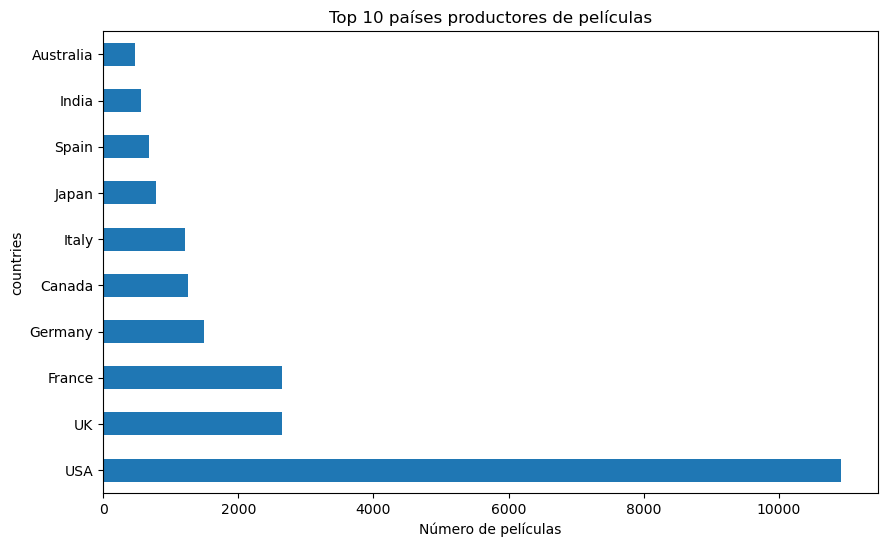

In [15]:
# Desanidar países y contar
countries_counts = movies.explode('countries')['countries'].value_counts().head(10)
print("\nK) Top 10 países con más películas:")
print(countries_counts)

# Visualización
countries_counts.plot(kind='barh', figsize=(10, 6), title='Top 10 países productores de películas')
plt.xlabel('Número de películas')
plt.show()